# Classification

## Model Pipeline

This notebook uses Random Forest Classification and Boosted Gradient Classifcation to predict whether a signal is LOS (0) or NLOS (1)

1. **Classification model** — predicts whether a signal is LOS (0) or NLOS (1)


In [1]:
import numpy as np


data = np.load("classification_data.npz")

X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]

print("Unique classes:", np.unique(y_train))
print("Train class counts:", np.bincount(y_train.astype(int)))
print("Test class counts: ", np.bincount(y_test.astype(int)))

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Unique classes: [0 1]
Train class counts: [16800 16800]
Test class counts:  [4200 4200]
Train shape: (33600, 103)
Test shape: (8400, 103)


Train shape: (33600, 103)
Test shape: (8400, 103)
----------------------------------------------------------------------
Training Gradient Boosting...
Training Random Forest...
MODEL: Gradient Boosting
Accuracy : 0.8937
F1       : 0.8903
Precision: 0.9196
Recall   : 0.8629

Confusion Matrix:
[[3883  317]
 [ 576 3624]]

Breakdown
TN: 3883
FP: 317
FN: 576
TP: 3624

Classification Report:
              precision    recall  f1-score   support

         LOS       0.87      0.92      0.90      4200
        NLOS       0.92      0.86      0.89      4200

    accuracy                           0.89      8400
   macro avg       0.90      0.89      0.89      8400
weighted avg       0.90      0.89      0.89      8400

MODEL: Random Forest
Accuracy : 0.8821
F1       : 0.8775
Precision: 0.9137
Recall   : 0.844

Confusion Matrix:
[[3865  335]
 [ 655 3545]]

Breakdown
TN: 3865
FP: 335
FN: 655
TP: 3545

Classification Report:
              precision    recall  f1-score   support

         LOS       0.8

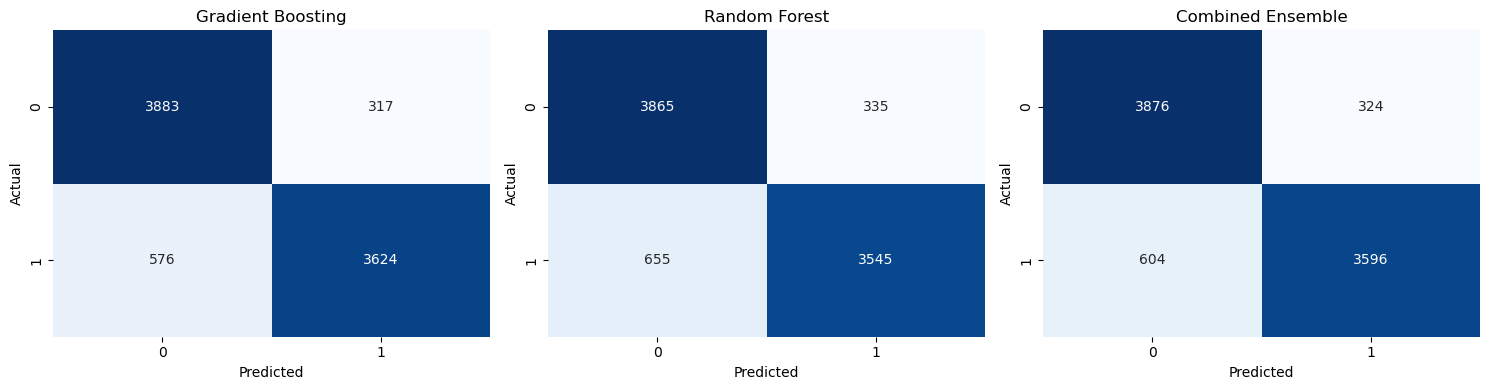

In [1]:
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Load data
# -----------------------------
data = np.load("classification_data.npz")

X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("-" * 70)

# -----------------------------
# Model 1: Gradient Boosting
# -----------------------------
gb_model = GradientBoostingClassifier(
    learning_rate=0.03,
    n_estimators=250,
    max_depth=10,
    subsample=1.0,
    min_samples_split=10,
    min_samples_leaf=10,
    random_state=42
)

# -----------------------------
# Model 2: Random Forest
# -----------------------------
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=24,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

# -----------------------------
# Train both models
# -----------------------------
print("Training Gradient Boosting...")
gb_model.fit(X_train, y_train)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
gb_pred = gb_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

# Probabilities for soft voting
gb_prob = gb_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# -----------------------------
# Combined prediction
# Option A: Soft voting (recommended)
# -----------------------------
combined_prob = (gb_prob + rf_prob) / 2
combined_pred = (combined_prob >= 0.5).astype(int)

# -----------------------------
# Helper function
# -----------------------------
def evaluate_model(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print("=" * 70)
    print(f"MODEL: {name}")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("F1       :", round(f1_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall   :", round(recall_score(y_true, y_pred), 4))
    print("\nConfusion Matrix:")
    print(cm)
    print("\nBreakdown")
    print("TN:", tn)
    print("FP:", fp)
    print("FN:", fn)
    print("TP:", tp)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["LOS", "NLOS"]))

    return cm

# -----------------------------
# Evaluate each model
# -----------------------------
cm_gb = evaluate_model("Gradient Boosting", y_test, gb_pred)
cm_rf = evaluate_model("Random Forest", y_test, rf_pred)
cm_combined = evaluate_model("Combined Ensemble (Soft Voting)", y_test, combined_pred)

# -----------------------------
# Optional: print all matrices neatly
# -----------------------------
print("=" * 70)
print("SUMMARY OF CONFUSION MATRICES")

print("\nGradient Boosting Confusion Matrix")
print(cm_gb)

print("\nRandom Forest Confusion Matrix")
print(cm_rf)

print("\nCombined Ensemble Confusion Matrix")
print(cm_combined)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

matrices = [cm_gb, cm_rf, cm_combined]
titles = ["Gradient Boosting", "Random Forest", "Combined Ensemble"]

for ax, cm, title in zip(axes, matrices, titles):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()